# Data Preprocessing

## Importing Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

import kagglehub
import glob

## Handling Missing Values

In [39]:
path = kagglehub.dataset_download("saurabhbadole/bank-customer-churn-prediction-dataset")

csv_path = glob.glob(f"{path}/*.csv")[0]

df = pd.read_csv(csv_path)

In [40]:
df.shape

(10000, 14)

In [41]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [43]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [44]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

## Outlier Detection & Handling

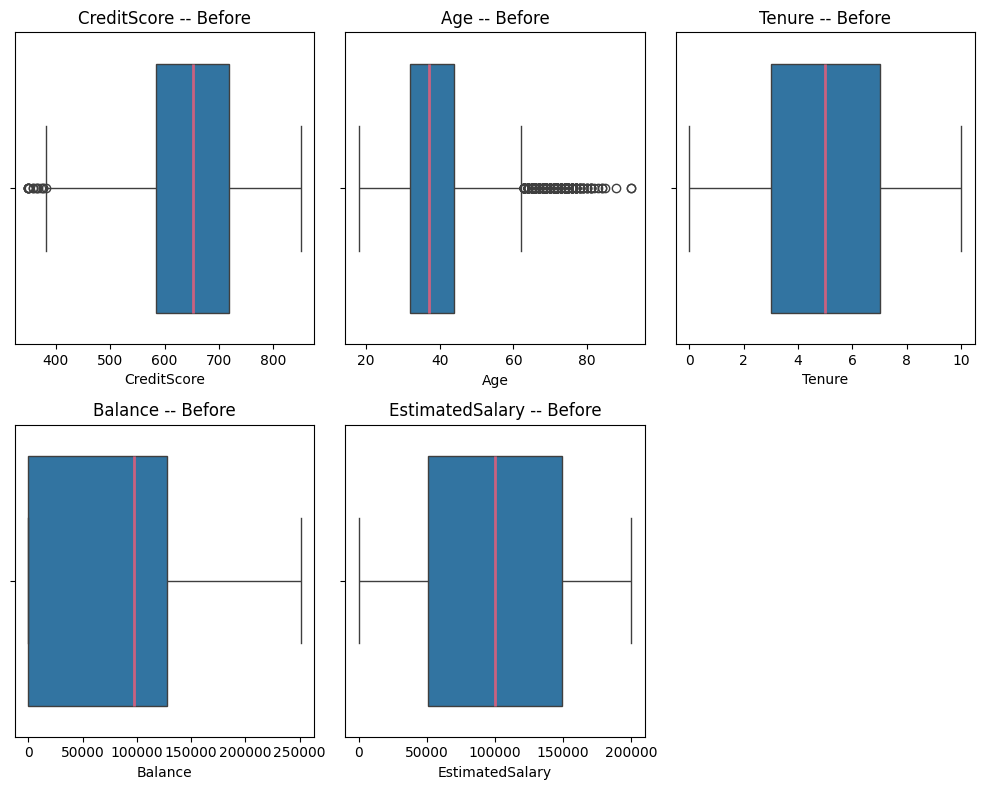

In [45]:
# continuous variables
continuous_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Detecting Outliers using boxplot
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(continuous_features):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2}
    )
    axes[i].set_title(f'{col} -- Before')

# Removing empty subplots
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [46]:
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [47]:
# Clipping Values out of IQR range
cols_with_outliers = ["Age","CreditScore"]

for col in cols_with_outliers:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

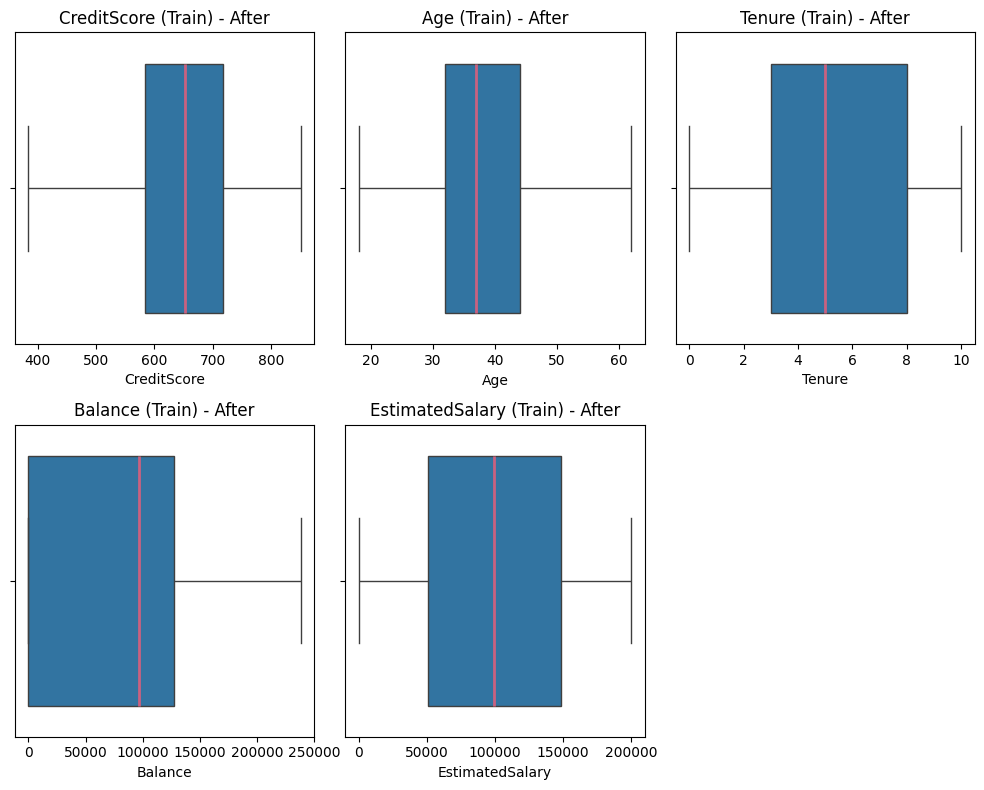

In [48]:
fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(continuous_features):
    sns.boxplot(
        x=X_train[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2}
    )
    axes[i].set_title(f'{col} (Train) - After')

# Removing empty subplots
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

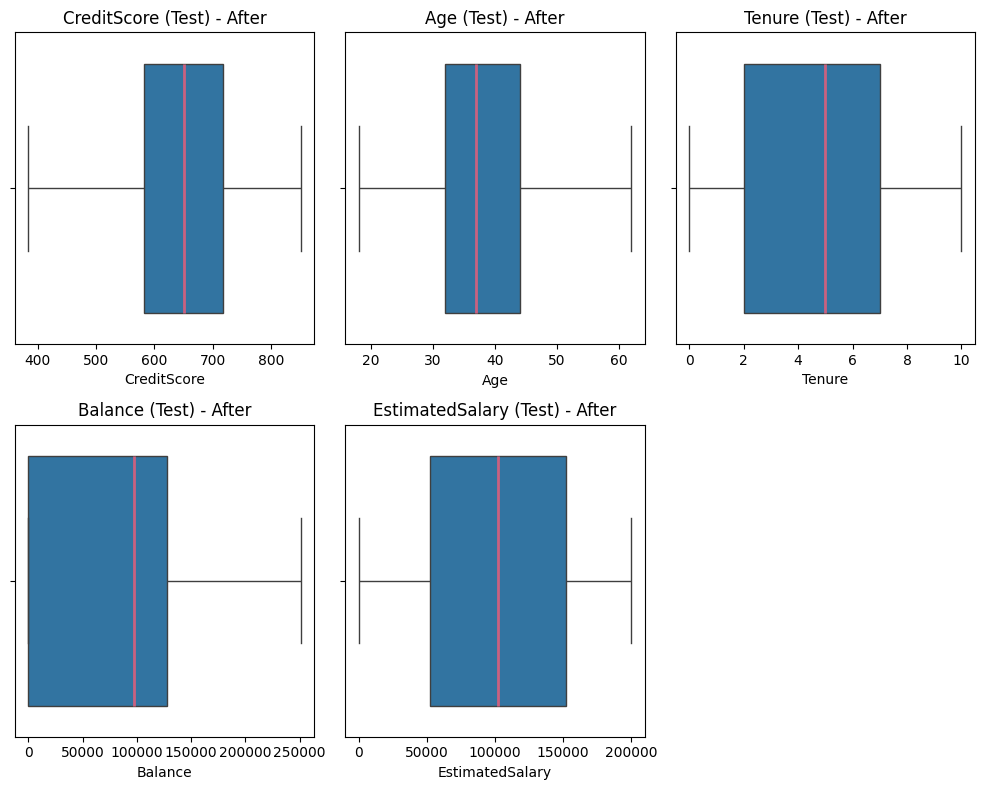

In [49]:
fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(continuous_features):
    sns.boxplot(
        x=X_test[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2}
    )
    axes[i].set_title(f'{col} (Test) - After')

# Removing empty subplots
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [50]:
X_train_unscaled = X_train.copy()

## Scaling

In [51]:
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [52]:
X_train.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.572046,0.469835,0.501663,0.320408,0.176500,0.708750,0.514875,0.498644
std,0.207293,0.221578,0.289679,0.261348,0.193914,0.454367,0.499810,0.286703
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.428571,0.318182,0.300000,0.000000,0.000000,0.000000,0.000000,0.253425
50%,0.574651,0.431818,0.500000,0.407132,0.000000,1.000000,1.000000,0.497224
75%,0.714286,0.590909,0.800000,0.535402,0.333333,1.000000,1.000000,0.742652
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Encoding

In [53]:
encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')

cat_cols = ['Geography', 'Gender']

X_train_cat_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_cat_encoded = encoder.transform(X_test[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_cat_encoded = pd.DataFrame(X_train_cat_encoded, columns=encoded_cols, index=X_train.index)
X_test_cat_encoded = pd.DataFrame(X_test_cat_encoded, columns=encoded_cols, index=X_test.index)


In [54]:
X_train_cat_encoded.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 2151 to 6206
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Geography_France   8000 non-null   float64
 1   Geography_Germany  8000 non-null   float64
 2   Geography_Spain    8000 non-null   float64
 3   Gender_Male        8000 non-null   float64
dtypes: float64(4)
memory usage: 312.5 KB


In [55]:
X_train_cat_encoded.head()

,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
2151,1.0,0.0,0.0,1.0
8392,0.0,1.0,0.0,1.0
5006,0.0,1.0,0.0,0.0
4117,1.0,0.0,0.0,1.0
7182,0.0,1.0,0.0,1.0


In [56]:
bi_cols = ['HasCrCard', 'IsActiveMember']

X_train_final = pd.concat([X_train[cols_to_scale], X_train_cat_encoded, X_train[bi_cols]], axis=1)
X_test_final = pd.concat([X_test[cols_to_scale], X_test_cat_encoded, X_test[bi_cols]], axis=1)

In [57]:
X_train_final.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 2151 to 6206
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        8000 non-null   float64
 1   Age                8000 non-null   float64
 2   Tenure             8000 non-null   float64
 3   Balance            8000 non-null   float64
 4   NumOfProducts      8000 non-null   float64
 5   EstimatedSalary    8000 non-null   float64
 6   Geography_France   8000 non-null   float64
 7   Geography_Germany  8000 non-null   float64
 8   Geography_Spain    8000 non-null   float64
 9   Gender_Male        8000 non-null   float64
 10  HasCrCard          8000 non-null   int64  
 11  IsActiveMember     8000 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 812.5 KB


In [58]:
X_train_final.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard,IsActiveMember
2151,0.791622,0.886364,0.7,0.000000,0.000000,0.797394,1.0,0.0,0.0,1.0,1,0
8392,0.761547,0.318182,0.3,0.428413,0.000000,0.319879,0.0,1.0,0.0,1.0,1,0
5006,0.795918,0.431818,0.0,0.477648,0.333333,0.586979,0.0,1.0,0.0,0.0,1,1
4117,0.379162,0.431818,0.5,0.000000,0.333333,0.415448,1.0,0.0,0.0,1.0,1,0
7182,0.660580,0.704545,0.6,0.463700,0.333333,0.537358,0.0,1.0,0.0,1.0,0,1


In [21]:
X_train_final.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard,IsActiveMember
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.572046,0.469835,0.501663,0.320408,0.176500,0.498644,0.499125,0.250625,0.250250,0.548375,0.708750,0.514875
std,0.207293,0.221578,0.289679,0.261348,0.193914,0.286703,0.500030,0.433400,0.433184,0.497685,0.454367,0.499810
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.428571,0.318182,0.300000,0.000000,0.000000,0.253425,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.574651,0.431818,0.500000,0.407132,0.000000,0.497224,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,0.714286,0.590909,0.800000,0.535402,0.333333,0.742652,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Dimensionality Reduction

In [22]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

print(f"New number of dimensions: {X_train_pca.shape[1]}")

New number of dimensions: 9


# Hierarchical Clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 2. Define the 3 linkage methods
linkage_methods = ['ward', 'complete', 'average']

# 3. Create the plot with a larger size to fix spacing issues
plt.figure(figsize=(12, 6))

# Loop through each method
for method in linkage_methods:
    silhouette_scores = []
    k_range = range(2, 11)

    print(f"Calculating for {method} linkage...")

    for k in k_range:
        # Create and fit model
        hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=method)
        labels = hc.fit_predict(X_train_pca)

        # Calculate score
        score = silhouette_score(X_train_pca, labels)
        silhouette_scores.append(score)

    # Plot the line for this method
    plt.plot(k_range, silhouette_scores, marker='o', label=f'{method} linkage')

# 4. Fixing the X-axis overlap and formatting the chart
plt.title('Silhouette Score Comparison for Different Linkages')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Force the X-axis to show specific integers clearly
plt.xticks(k_range)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend() # Show which color belongs to which method
plt.show()

In [ ]:
# Calculating WCSS for Elbow Method (Simple Loop)
wcss_scores = []
k_range = range(2, 11)

for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(X_train_pca)

    # Calculating Centroids manually
    centroids = []
    for i in range(k):
        # Taking mean of points in each cluster
        centroids.append(X_train_pca[labels == i].mean(axis=0))
    centroids = np.array(centroids)

    # Calculating WCSS (Sum of squared distances)
    wcss = 0
    for i in range(k):
        cluster_points = X_train_pca[labels == i]
        wcss += np.sum((cluster_points - centroids[i]) ** 2)
    wcss_scores.append(wcss)

# Plotting Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_scores, marker='o', color='red')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# 1. Applying the model with the chosen K (e.g., K=4)
from sklearn.cluster import AgglomerativeClustering

best_k = 4 # Change this based on your observation
hc_final = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
y_hc = hc_final.fit_predict(X_train_pca)

# 2. Adding labels to original data to analyze
X_train_copy = X_train.copy() # Using the original data before PCA for interpretation
X_train_copy['Cluster_Label'] = y_hc

# 3. Profiling (Analysis) - Print means for numeric features
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
cluster_profile = X_train_copy.groupby('Cluster_Label')[numeric_features].mean()

print(cluster_profile)

# Optional: Plotting a simple bar chart for 'Age' to visualize
cluster_profile['Age'].plot(kind='bar', color='skyblue')
plt.title('Average Age per Cluster')
plt.ylabel('Average Age')
plt.show()

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# 1. Calculate Linkage
# 'ward' is common, but you can change to 'single' or 'complete' to see different trees
Z = sch.linkage(X_train_pca, method='ward')

# 2. Plot the Dendrogram
plt.figure(figsize=(15, 7))

# truncate_mode='lastp', p=15
dendrogram = sch.dendrogram(Z, truncate_mode='lastp', p=15, show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (Tree)')
plt.xlabel('Cluster Size or Customers')
plt.ylabel('Euclidean Distance')
plt.show()

# K-Medoid Clustering

In [16]:
from sklearn_extra.cluster import KMedoids

In [20]:
# Choose numeric data and scalling them
X = df.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [18]:
X_scaled = X_train.select_dtypes(include=[np.number])

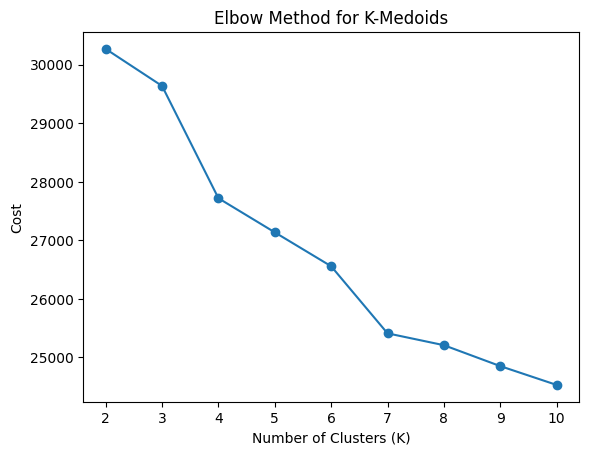

In [21]:
# Elbow Method

costs = [] # To collect all costs here

# Build K-Medoids Model
K_range = range(2,11)
for k in K_range:
  model = KMedoids(n_clusters=k, random_state=42, method='alternate')
  model.fit(X_scaled)

  cost = 0

  for i in range(len(X_scaled)): # Compute all costs
    cost += np.min(cdist([X_scaled[i]], model.cluster_centers_))

  costs.append(cost)

 # Draw Elbow Method Curve
plt.plot(K_range, costs, marker='o')
plt.title("Elbow Method for K-Medoids")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost")
plt.show()

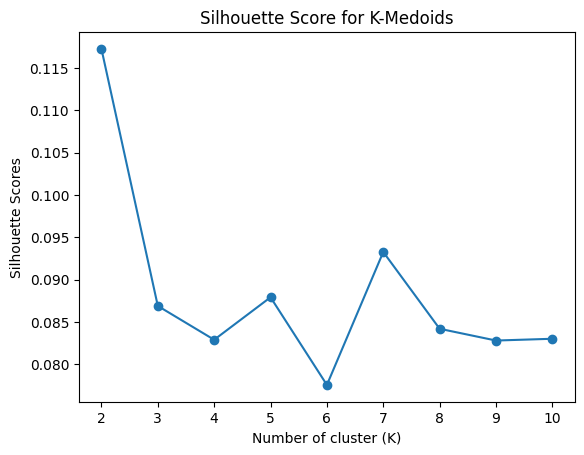

In [22]:
# Silhouette Score

sil_scores = [] # Collect all scores here

for k in K_range:
  model = KMedoids(n_clusters=k, random_state=42, method='alternate')
  labels = model.fit_predict(X_scaled) # train & get labels

  score = silhouette_score(X_scaled , labels)
  sil_scores.append(score) # All scores for all points

# Draw Silhouette score plot
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score for K-Medoids")
plt.xlabel("Number of cluster (K)")
plt.ylabel("Silhouette Scores")
plt.show()


In [23]:
# Choose the best K and Building the final model
best_k = 3 # depends on the Elbow_method & Silhouette_Score plots
final_model = KMedoids(n_clusters = best_k, random_state=42, method='alternate')
df['Cluster'] = final_model.fit_predict(X_scaled) # Add cluster column to data frame to classify which cluster each point belongs to

In [24]:
# Cluster Profiling
cluster_profile = df.select_dtypes(include=['number']).groupby('Cluster').mean()
print(cluster_profile)

         CreditScore        Age    Tenure        Balance  NumOfProducts  \
Cluster                                                                   
0         648.588010  38.259779  5.086310   51212.624152       2.079932   
1         617.768589  42.096737  6.963202  104149.322470       1.034143   
2         686.425564  36.946241  2.950000   93765.825128       1.049624   

         HasCrCard  IsActiveMember  EstimatedSalary    Exited  
Cluster                                                        
0         0.706420        0.524660    102434.142942  0.131378  
1         0.712064        0.499241     82120.846851  0.299317  
2         0.697368        0.513910    113752.495530  0.236842  


In [25]:
# Visualize the final result of K-Medoids
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis')
plt.title("K-Medoids Clustering Result")
plt.show()

NameError: name 'X_pca' is not defined

<Figure size 800x600 with 0 Axes>

# FUZZY LOGIC INFERENCE SYSTEM (FIS)

## FUZZY LOGIC OVERVIEW

## INPUT 1:
The FIS will use the output from the K-Medoids model **(Assuming 3 segments: Low/Medium/High risk of churn)**
## INPUT 2:
This will be the balance of the Customer: **ZERO/Low/Medium/High balance**.
## OUTPUT (THE DECISION):
The decision our system is going to make is how much the bank will prioritize this specific customer. \
**PRIORITY:  Range: (0-100)**\
**Low Priority** customers will be provided with no action. \
**Medium Priority** customers will get an automated email or maybe a discount voucher.\
**HIGH PRIORITY (VIP PRIO)** will get an immediate manager call to try to keep the customer from churning. 

## Defining fuzzy sets for balance
Balance range (after scaling) -> [0-1]\
Based on the balance distribution, 

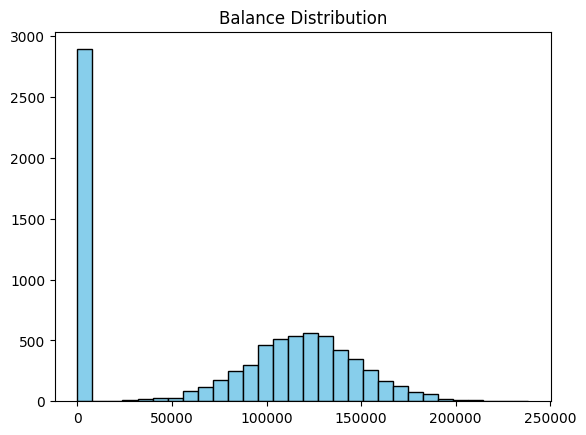

In [79]:
plt.hist(x=X_train_unscaled['Balance'], bins=30, color='skyblue', edgecolor='black')
plt.title("Balance Distribution")
plt.show()

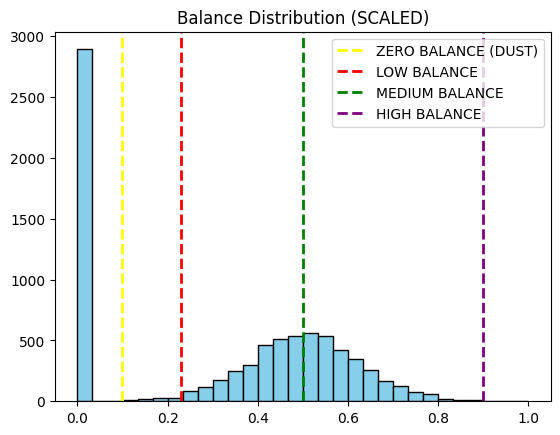

In [89]:
plt.hist(x=X_train_final['Balance'], bins=30, color='skyblue', edgecolor='black')
plt.title("Balance Distribution (SCALED)")

plt.axvline(x=.1, color='yellow', linestyle='--', linewidth=2, label="ZERO BALANCE (DUST)")
plt.axvline(x=.23, color='red', linestyle='--', linewidth=2, label="LOW BALANCE")
plt.axvline(x=.5, color='green', linestyle='--', linewidth=2, label="MEDIUM BALANCE")
plt.axvline(x=.9, color='purple', linestyle='--', linewidth=2, label="HIGH BALANCE")

plt.legend()
plt.show()

## Fuzzy Sets

In [81]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [82]:
# CODE: DEFINING ANTECEDENTS (INPUTS)  ⬇️ 
# Churn Risk: Range (0-1)
# Balance: Range (0-1)




In [83]:
# CODE: DEFINING CONSEQUENT (OUTPUTS) ⬇️
# PRIORITY SCORE (0-100)




## Membership Functions

#### 1. Input Variable: Balance
Based on the histogram analysis, the following membership functions are defined to handle the input from account balance

| Fuzzy Set | Shape | Coordinates | Logic |
| :--- | :--- | :--- | :--- |
| **Dust/Zero** | Trapezoid | $[0, 0, 0.05, 0.1]$ | Customer with zero (or near zero) funds |
| **Low** | Triangle | $[0.05, 0.2, 0.4]$ | Small accounts with low funds |
| **Medium** | Triangle | $[0.3, 0.5, 0.7]$ | Average customers |
| **High** | Trapezoid | $[0.6, 0.8, 1.0, 1.0]$ | VIPs and High-value individuals |

In [84]:
# CODE: DEFINING MF FOR BALANCE  ⬇️





#### 2. Input Variable: Cluster Risk
Mapped from K-Medoids clustering based on the churn rate of each cluster.

**NOTE FOR LATER:**\
If Cluster_ID is in the Low Risk Cluster $\rightarrow$ Input value = 0.0\
If Cluster_ID is in the Med Risk Cluster $\rightarrow$ Input value = 0.5\
If Cluster_ID is in the Critical Cluster $\rightarrow$ Input value = 1.0


| Fuzzy Set | Shape | Coordinates  | Description |
| :--- | :--- | :--- | :--- |
| **Low Risk** | Triangle | $[0, 0, 0.4]$ | Cluster with the lowest churn rate. |
| **Medium Risk** | Triangle | $[.2, 0.5, .8]$ | Cluster with moderate churn rate. |
| **Critical** | Triangle | $[0.6, 1, 1]$ | Cluster with the highest churn rate. |

#### 3. Output Variable: Priority Score (0-100)
How hard is the bank going to try to keep the customer from churning

| Fuzzy Set | Shape | Coordinates | Action / Decision |
| :--- | :--- | :--- | :--- |
| **Low Prio** | Trapezoid | $[0, 0, 20, 40]$ | No resources spent |
| **Med Prio** | Triangle | $[30, 50, 70]$ | Automated marketing email or discount offers. |
| **High Prio (VIP)** | Trapezoid | $[60, 80, 100, 100]$ | Call from mangement or sales team |

In [ ]:
# CODE: DEFINING MF FOR PS ⬇️



